# Import Libraries

In [1]:
# !pip install pycaret
# !pip install optuna
# !pip install optuna-integration[sklearn]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import *

# Read the .xlsx file as a dataframe

In [3]:
from urllib.request import urlretrieve
from pathlib import Path

if not Path("/content/rooster_a3_pricing.xlsx").exists():
    urlretrieve("https://drive.google.com/uc?export=download&id=1gCewYYyrVFquTf8R8EzPWvsdWSi7r8yP", "rooster_a3_pricing.xlsx")

In [4]:
file_path = '/content/rooster_a3_pricing.xlsx'

In [5]:
sheet_names = pd.ExcelFile(file_path).sheet_names

for sheet in sheet_names:
    globals()[f"{sheet}_df"] = pd.read_excel(file_path, sheet_name=sheet)

# Checking dataframe structure and null counts

In [6]:
for sheet in sheet_names:
    print(sheet)
    globals()[f"{sheet}_df"].info()
    print('\n\n')

customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9131 entries, 0 to 9130
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_email             9131 non-null   object        
 1   customer_first_order_date  9131 non-null   datetime64[ns]
 2   customer_last_order_date   9131 non-null   datetime64[ns]
 3   customer_total_orders      9131 non-null   int64         
 4   customer_total_spent       9131 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 356.8+ KB



orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12028 entries, 0 to 12027
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 12028 non-null  object        
 1   customer_email           12028 non-null  object      

# Customer Analysis

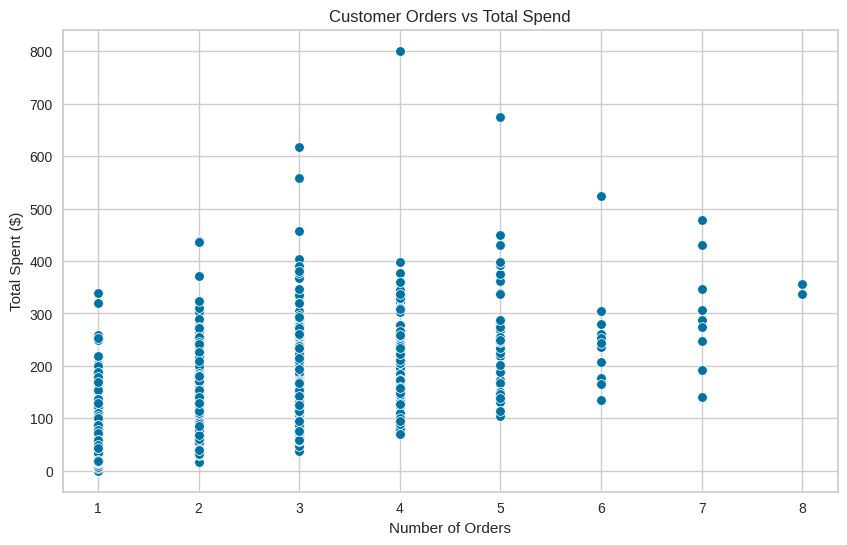

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers_df, x='customer_total_orders', y='customer_total_spent')
plt.title('Customer Orders vs Total Spend')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spent ($)')
plt.show()

# Product Analysis

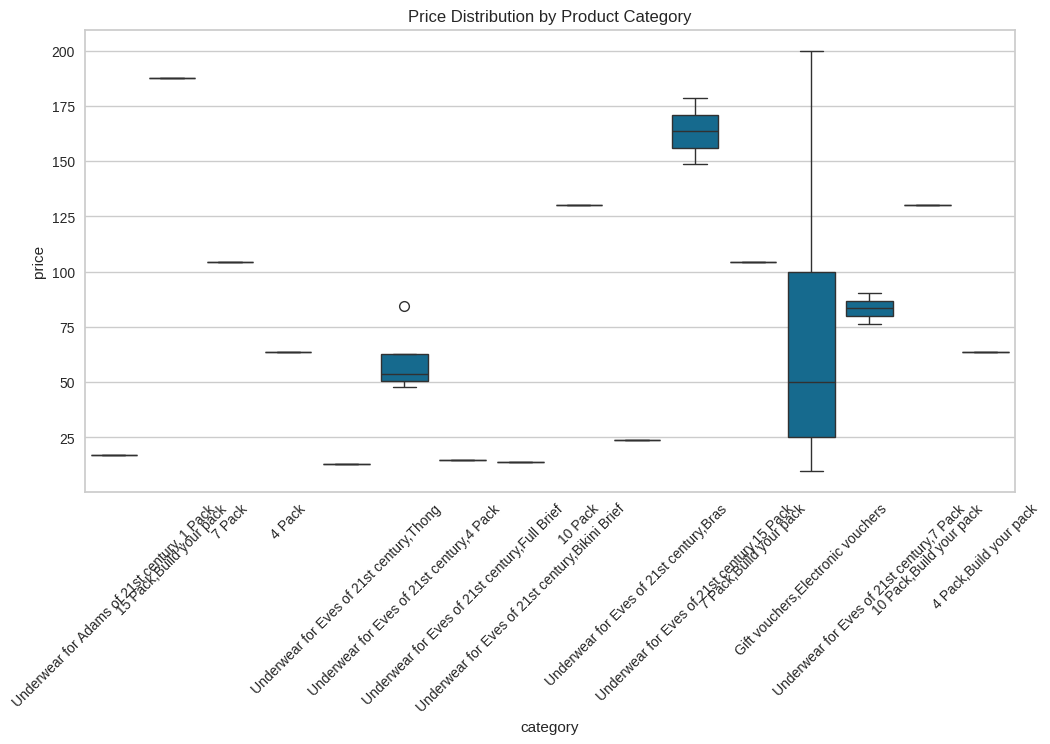

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=products_df, x='category', y='price')
plt.xticks(rotation=45)
plt.title('Price Distribution by Product Category')
plt.show()

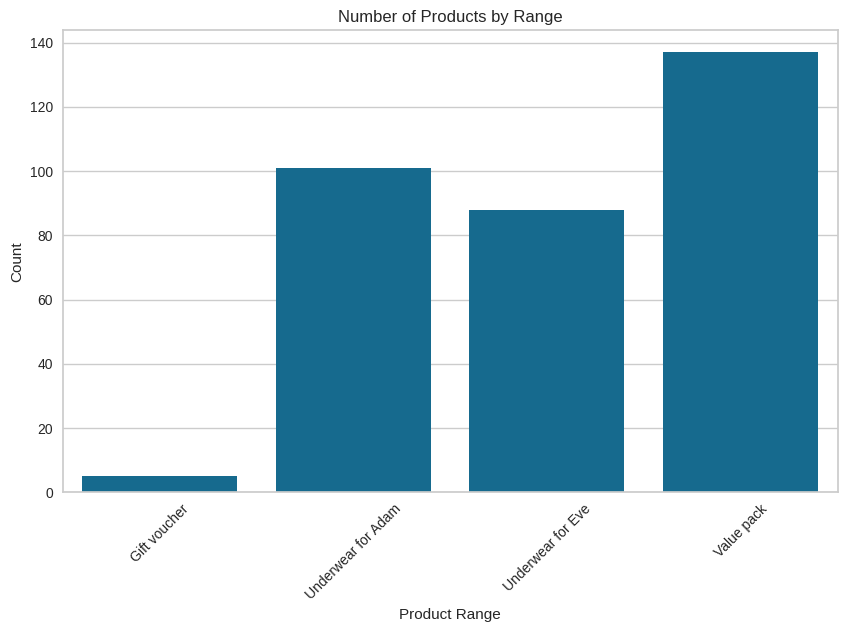

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=products_df.groupby('range')['product_id'].count().reset_index(),
            x='range', y='product_id')
plt.title('Number of Products by Range')
plt.xlabel('Product Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Order Analysis

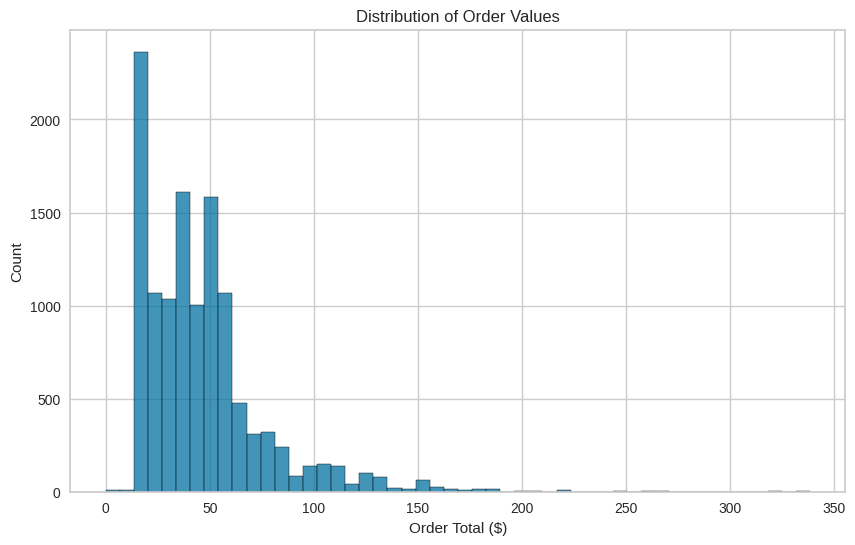

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=orders_df, x='order_total', bins=50)
plt.title('Distribution of Order Values')
plt.xlabel('Order Total ($)')
plt.ylabel('Count')
plt.show()

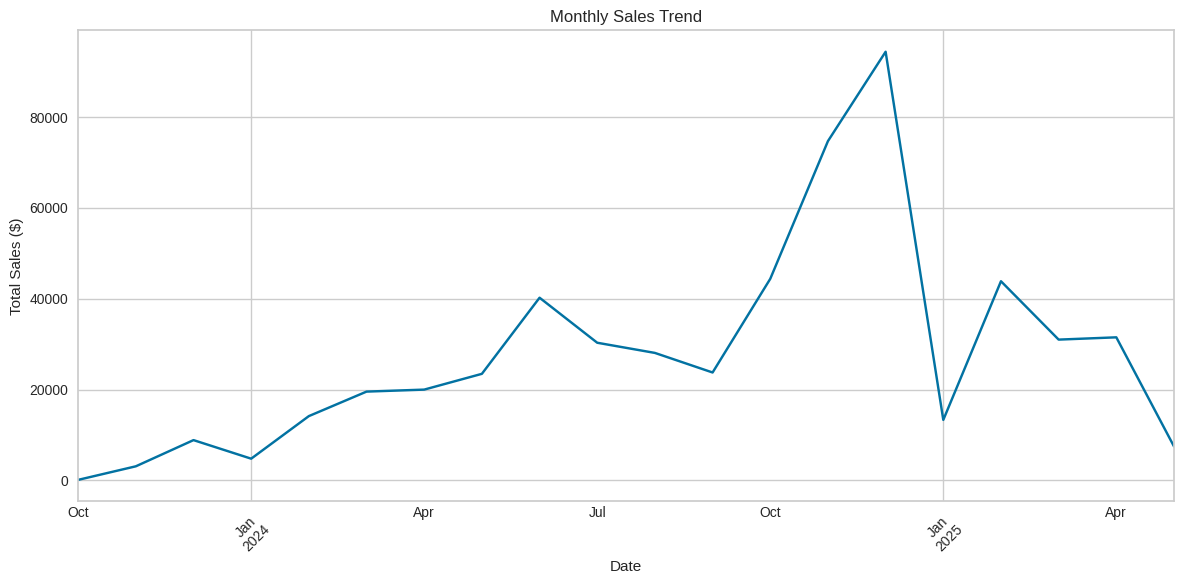

In [11]:
# Time series analysis of orders
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
monthly_orders = orders_df.resample('M', on='order_date')['order_total'].sum()

plt.figure(figsize=(12, 6))
monthly_orders.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

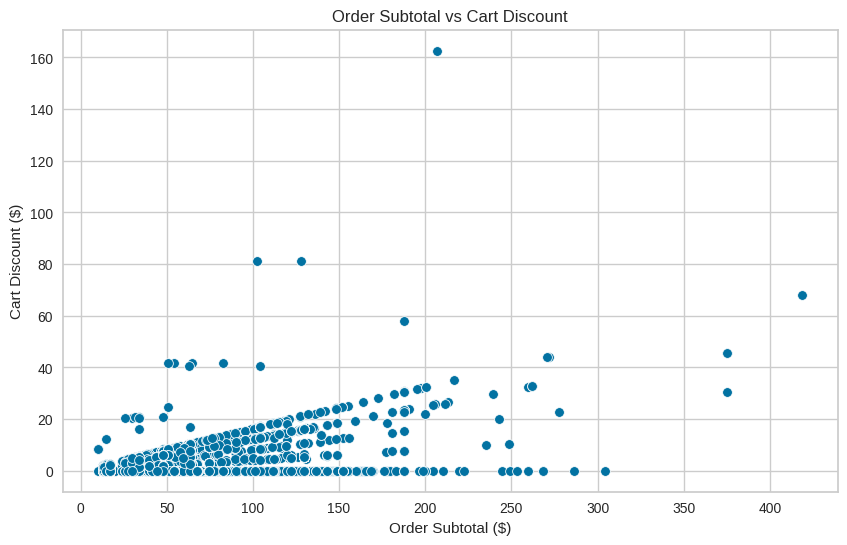

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=orders_df, x='order_subtotal_inc_tax', y='cart_discount')
plt.title('Order Subtotal vs Cart Discount')
plt.xlabel('Order Subtotal ($)')
plt.ylabel('Cart Discount ($)')
plt.show()

# Order Lines Analysis

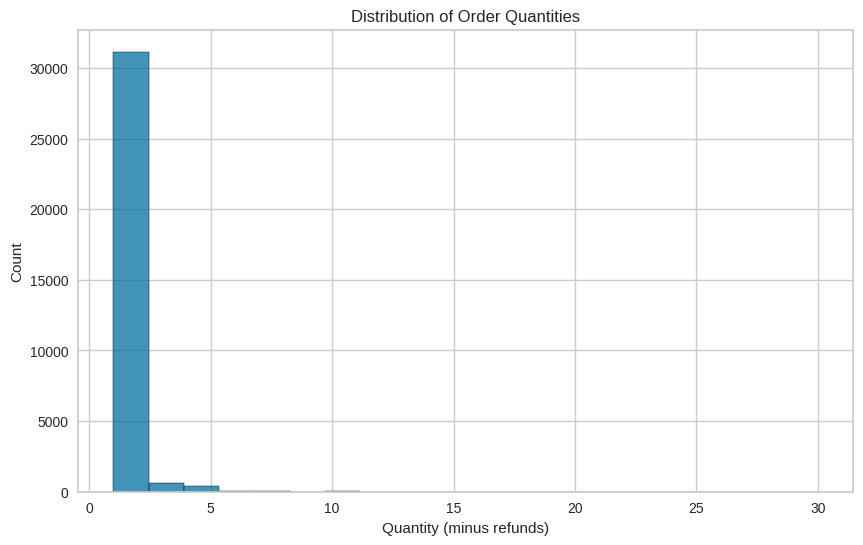

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=orderlines_df, x='qty_minus_refund', bins=20)
plt.title('Distribution of Order Quantities')
plt.xlabel('Quantity (minus refunds)')
plt.ylabel('Count')
plt.show()

# Summary Stats

In [14]:
customer_stats = customers_df.agg({
    'customer_total_orders': ['mean', 'median', 'std', 'min', 'max'],
    'customer_total_spent': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print("Customer Statistics:")
print(customer_stats)

Customer Statistics:
        customer_total_orders  customer_total_spent
mean                     1.32                 61.03
median                   1.00                 45.20
std                      0.70                 53.59
min                      1.00                  0.00
max                      8.00                801.09


In [15]:
order_stats = orders_df.agg({
    'order_total': ['mean', 'median', 'std', 'min', 'max'],
    'order_subtotal_inc_tax': ['mean', 'median', 'std', 'min', 'max'],
    'cart_discount': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print("\nOrder Statistics:")
print(order_stats)


Order Statistics:
        order_total  order_subtotal_inc_tax  cart_discount
mean          46.33                   45.37           1.87
median        40.05                   39.90           0.00
std           29.72                   32.38           4.37
min            0.00                   10.00           0.00
max          338.50                  418.80         162.60


In [16]:
product_stats = products_df.groupby('category')['price'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(2)

print("\nProduct Price Statistics by Category:")
print(product_stats)


Product Price Statistics by Category:
                                                 count   mean  median    std  \
category                                                                       
10 Pack                                              4  129.9   129.9   0.00   
10 Pack,Build your pack                              1  129.9   129.9    NaN   
15 Pack,Build your pack                              1  187.5   187.5    NaN   
4 Pack                                              81   63.6    63.6   0.00   
4 Pack,Build your pack                               4   63.6    63.6   0.00   
7 Pack                                              43  104.3   104.3   0.00   
7 Pack,Build your pack                               3  104.3   104.3   0.00   
Gift vouchers,Electronic vouchers                    5   77.0    50.0  76.78   
Underwear for Adams of 21st century, 1 Pack        101   16.9    16.9   0.00   
Underwear for Eves of 21st century,15 Pack           3  163.5   163.5  15.00   
U

In [17]:
orderline_stats = orderlines_df.agg({
    'qty_minus_refund': ['mean', 'median', 'std', 'min', 'max'],
    'item_price_inc_tax': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print("\nOrderline Statistics:")
print(orderline_stats)


Orderline Statistics:
        qty_minus_refund  item_price_inc_tax
mean                1.21               15.60
median              1.00               12.90
std                 0.73               22.88
min                 1.00                0.00
max                30.00              187.50


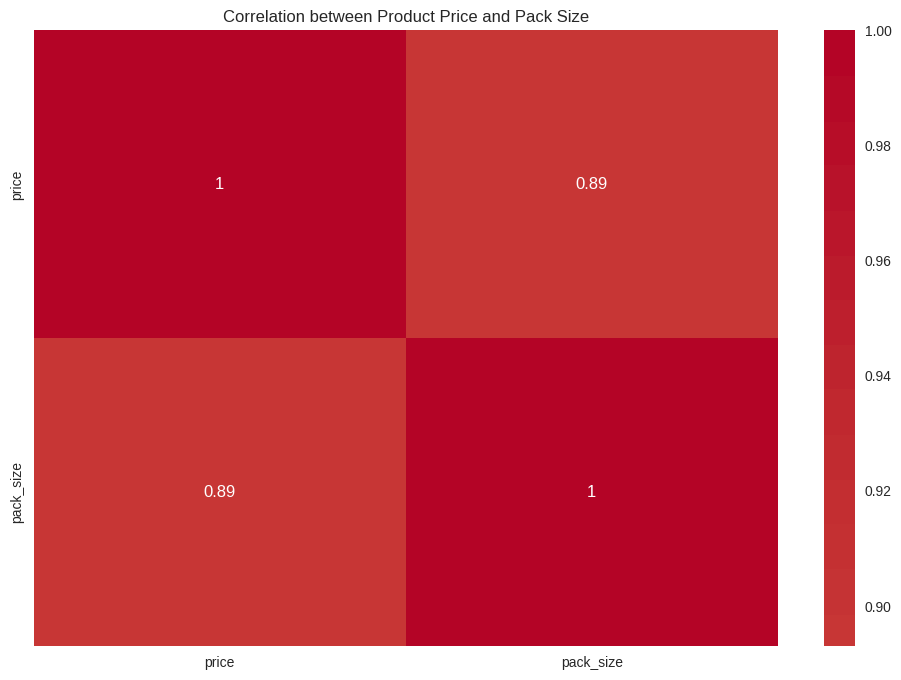

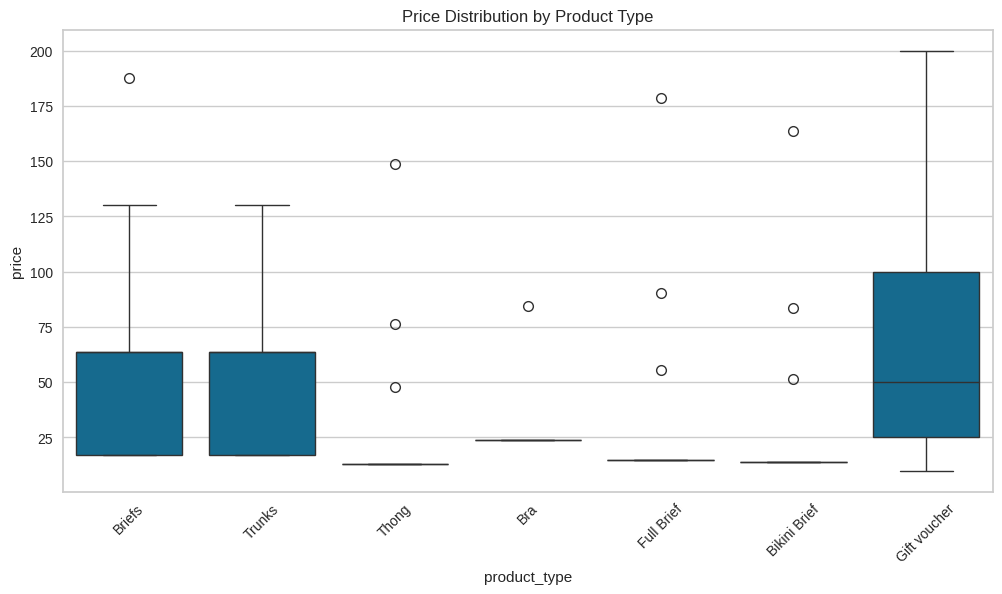

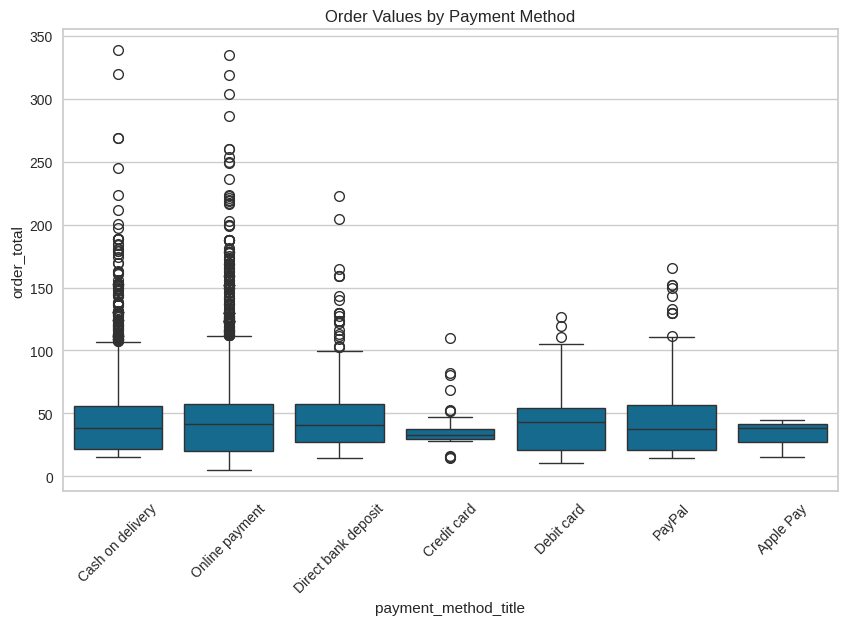

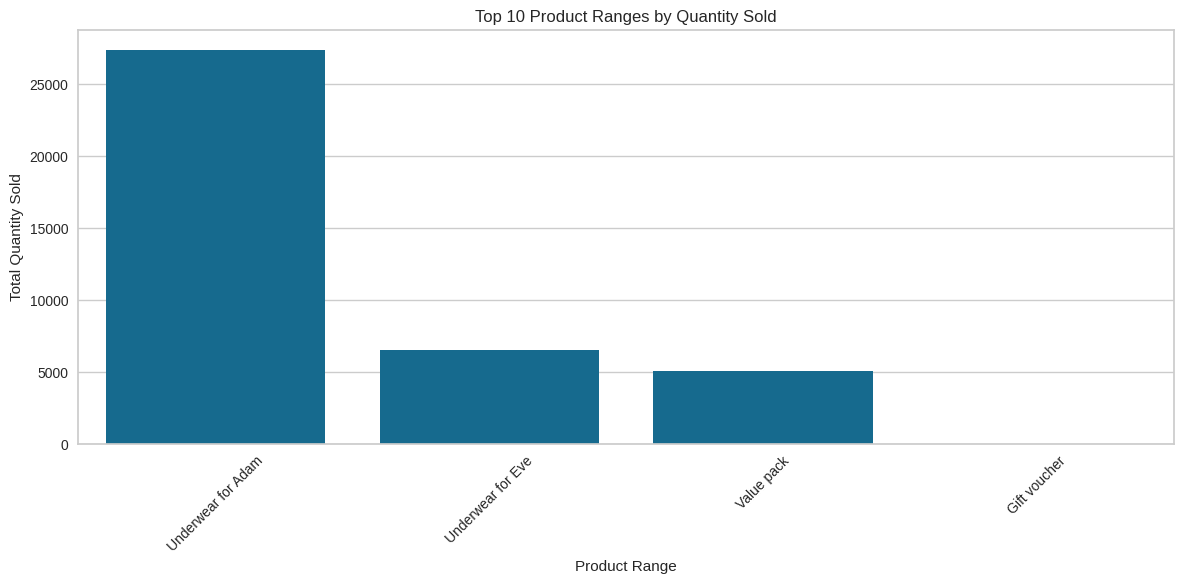

In [18]:
# Create correlation matrix visualization
plt.figure(figsize=(12, 8))
corr = products_df[['price', 'pack_size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Product Price and Pack Size')
plt.show()

# Create price distribution by product type
plt.figure(figsize=(12, 6))
sns.boxplot(data=products_df, x='product_type', y='price')
plt.xticks(rotation=45)
plt.title('Price Distribution by Product Type')
plt.show()

# Analyze order values by payment method
plt.figure(figsize=(10, 6))
sns.boxplot(data=orders_df, x='payment_method_title', y='order_total')
plt.xticks(rotation=45)
plt.title('Order Values by Payment Method')
plt.show()

# Show top product ranges by total quantity sold
top_ranges = orderlines_df.merge(products_df[['pvr_id', 'range']], on='pvr_id') \
    .groupby('range')['qty_minus_refund'].sum() \
    .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_ranges.index, y=top_ranges.values)
plt.xticks(rotation=45)
plt.title('Top 10 Product Ranges by Quantity Sold')
plt.xlabel('Product Range')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

In [19]:
price_pack_outliers = products_df[
    (products_df['price'] > products_df['price'].quantile(0.95)) |
    (products_df['pack_size'] > products_df['pack_size'].quantile(0.95))
    ]

print("Products with extreme prices or pack sizes:")
print(price_pack_outliers[['product_name_main', 'price', 'pack_size', 'category']])

Products with extreme prices or pack sizes:
                                     product_name_main  price  pack_size  \
6    Rooster Trunks / Briefs (custom colour selecti...  187.5         15   
65   Rooster Trunks Midnight in Eden Black 10pack v...  129.9         10   
66   Rooster Trunks Midnight in Eden Black 10pack v...  129.9         10   
67   Rooster Trunks Midnight in Eden Black 10pack v...  129.9         10   
68   Rooster Trunks Midnight in Eden Black 10pack v...  129.9         10   
83   Chickadee Thong (custom colour selection) 15 P...  148.5         15   
164  Chickadee Bikini Brief (custom colour selectio...  163.5         15   
257  Rooster Trunks / Briefs (custom colour selecti...  129.9         10   
258        Rooster Gift voucher in the amount of 200 $  200.0          1   
330  Chickadee Full Brief (custom colour selection)...  178.5         15   

                                       category  
6                       15 Pack,Build your pack  
65                 

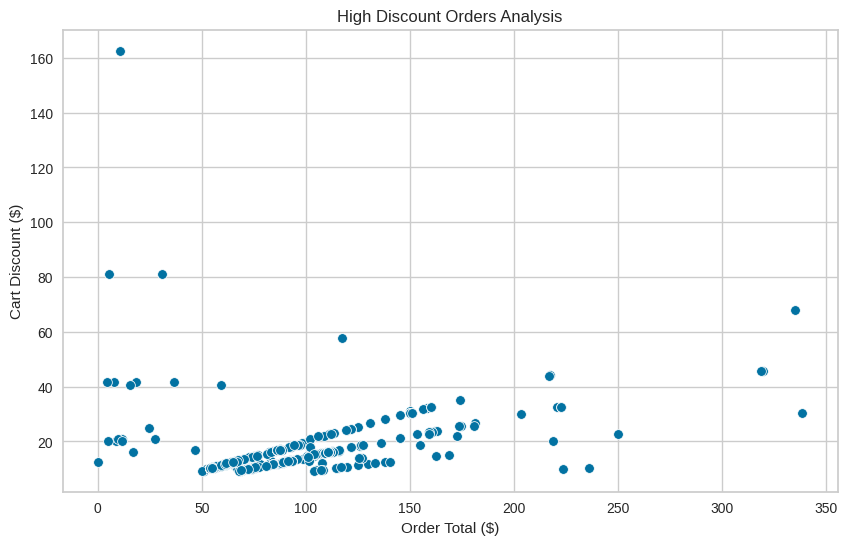

In [20]:
high_discount_orders = orders_df[
    orders_df['cart_discount'] > orders_df['cart_discount'].quantile(0.95)
    ]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=high_discount_orders, x='order_total', y='cart_discount')
plt.title('High Discount Orders Analysis')
plt.xlabel('Order Total ($)')
plt.ylabel('Cart Discount ($)')
plt.show()

In [21]:
unusual_customers = customers_df[
    (customers_df['customer_total_orders'] > customers_df['customer_total_orders'].quantile(0.95)) |
    (customers_df['customer_total_spent'] > customers_df['customer_total_spent'].quantile(0.95))
    ]

print("\nCustomers with unusual ordering patterns:")
print(unusual_customers[['customer_total_orders', 'customer_total_spent']])


Customers with unusual ordering patterns:
      customer_total_orders  customer_total_spent
14                        3                178.93
41                        4                236.37
53                        4                307.44
59                        1                168.60
63                        2                312.50
...                     ...                   ...
9059                      3                166.40
9062                      2                181.61
9066                      3                234.69
9081                      2                226.51
9094                      2                209.30

[503 rows x 2 columns]



Refund Statistics:
count     2.000000
mean     30.110000
std      21.510188
min      14.900000
25%      22.505000
50%      30.110000
75%      37.715000
max      45.320000
Name: order_refund, dtype: float64


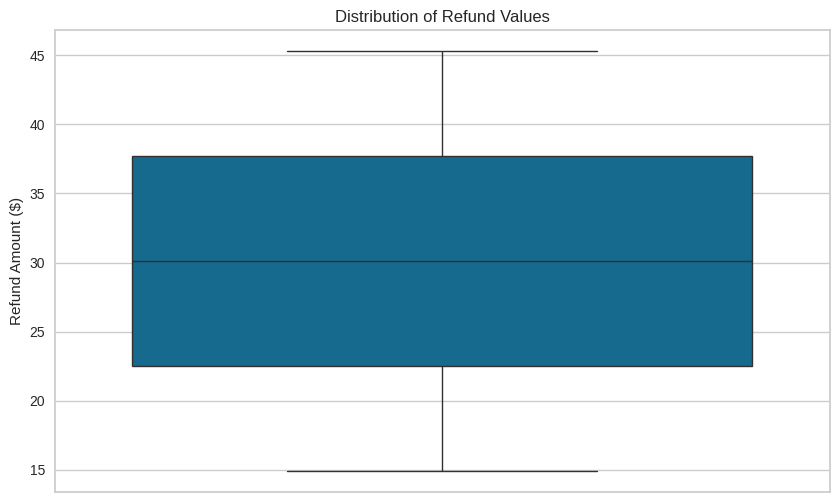

In [22]:
refund_analysis = orders_df[orders_df['order_refund'] > 0]
print("\nRefund Statistics:")
print(refund_analysis['order_refund'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(data=refund_analysis, y='order_refund')
plt.title('Distribution of Refund Values')
plt.ylabel('Refund Amount ($)')
plt.show()

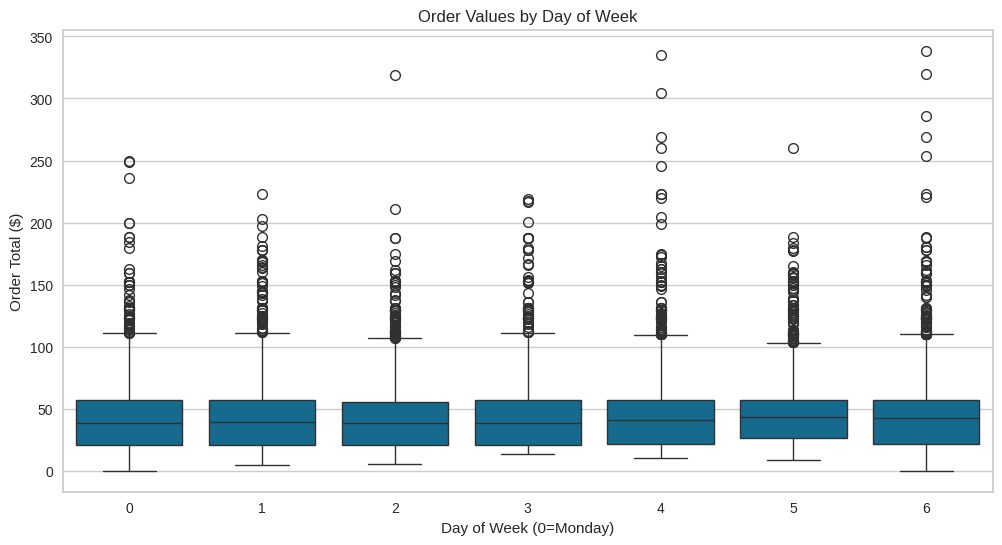

In [23]:
orders_df['order_hour'] = orders_df['order_date'].dt.hour
orders_df['order_dow'] = orders_df['order_date'].dt.dayofweek

plt.figure(figsize=(12, 6))
sns.boxplot(data=orders_df, x='order_dow', y='order_total')
plt.title('Order Values by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Order Total ($)')
plt.show()

# Predictive Modelling

In [24]:
merged_df = (
    orderlines_df
    .merge(orders_df,      on='order_id')
    .merge(products_df,    on='pvr_id')
    .rename(columns={'item_price_before_discount':'cost'})
)

In [25]:
len(merged_df),len(orderlines_df)


(32296, 32296)

In [26]:
prod_summary = (
    merged_df
    .groupby(['pvr_id','product_name_main'])
    .agg(
        old_qty   = ('qty_minus_refund','sum'),
        avg_cost  = ('cost',            'mean'),
        avg_price = ('price',           'mean'),
        num_orders= ('order_id',        'nunique'),
        num_lines = ('line_id',         'count')
    )
    .reset_index()
    .rename(columns={'avg_price':'old_price',
                     'product_name_main':'product_name'})
)

In [27]:
agg_data = prod_summary.drop(columns=['pvr_id','product_name'])
exp_agg  = setup(data=agg_data, target='old_qty', verbose=False)
best_agg = compare_models()
final_agg= finalize_model(best_agg)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,14.0675,1618.8785,33.9544,0.9831,0.2653,0.3066,0.0270
lr,Linear Regression,16.0862,1318.7467,33.9974,0.9814,0.4956,0.8191,0.5180
ridge,Ridge Regression,16.1073,1325.7206,34.0560,0.9813,0.4979,0.8200,0.0130
llar,Lasso Least Angle Regression,16.5593,1502.7976,35.4514,0.9799,0.5004,0.8122,0.0140
par,Passive Aggressive Regressor,16.8659,2134.0973,38.3969,0.9792,0.3206,0.6202,0.0140
lasso,Lasso Regression,17.8098,1806.3862,37.3813,0.9781,0.6387,1.3732,0.0170
en,Elastic Net,17.8119,1806.2691,37.3828,0.9781,0.6399,1.3750,0.0150
omp,Orthogonal Matching Pursuit,16.3829,1897.5831,37.7536,0.9779,0.2922,0.4314,0.0150
br,Bayesian Ridge,17.1586,1706.7324,36.8576,0.9778,0.5196,0.8297,0.0140
et,Extra Trees Regressor,14.3425,2025.5719,35.2295,0.9756,0.1488,0.0943,0.1040


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [28]:
# Advanced tuning with Optuna
tuned_model = tune_model(
    final_agg,
    optimize='RMSE',
    n_iter=50,
    search_library='optuna',
    #early_stopping=True,
    early_stopping_max_iters=10
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.6116,326.4307,18.0674,0.9952,0.2044,0.2950
1,21.8845,4989.3273,70.6352,0.9692,0.5279,0.8019
2,6.4618,122.7944,11.0813,0.9811,0.3878,0.7143
3,13.4337,910.6079,30.1763,0.9810,0.1700,0.3057
4,15.9210,1687.0909,41.0742,0.9755,0.2184,0.2774
5,9.5153,201.8494,14.2074,0.9907,0.4145,0.6024
6,9.5136,246.1436,15.6890,0.9910,0.2861,0.5262
7,23.4894,4564.4931,67.5610,0.9785,0.3131,0.3662
8,13.2028,754.6219,27.4704,0.9881,0.4171,0.3514


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 225 samples...
INFO:optuna_integration.sklearn.sklearn:Finished hyperparameter search!


In [29]:
# Create stacked model
top_models = compare_models(sort='R2', n_select=3)
stacked_model = stack_models(estimator_list=top_models, meta_model=tuned_model, optimize='RMSE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,14.0675,1618.8785,33.9544,0.9831,0.2653,0.3066,0.0280
lr,Linear Regression,16.0862,1318.7467,33.9974,0.9814,0.4956,0.8191,0.0140
ridge,Ridge Regression,16.1073,1325.7206,34.0560,0.9813,0.4979,0.8200,0.0150
llar,Lasso Least Angle Regression,16.5593,1502.7976,35.4514,0.9799,0.5004,0.8122,0.0150
par,Passive Aggressive Regressor,16.8659,2134.0973,38.3969,0.9792,0.3206,0.6202,0.0140
lasso,Lasso Regression,17.8098,1806.3862,37.3813,0.9781,0.6387,1.3732,0.0170
en,Elastic Net,17.8119,1806.2691,37.3828,0.9781,0.6399,1.3750,0.0150
omp,Orthogonal Matching Pursuit,16.3829,1897.5831,37.7536,0.9779,0.2922,0.4314,0.0150
br,Bayesian Ridge,17.1586,1706.7324,36.8576,0.9778,0.5196,0.8297,0.0140
et,Extra Trees Regressor,14.3425,2025.5719,35.2295,0.9756,0.1488,0.0943,0.1060


Processing:   0%|          | 0/83 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.0482,305.0698,17.4662,0.9955,0.2080,0.2583
1,21.7889,5234.4683,72.3496,0.9677,0.3970,0.5443
2,5.9193,125.7849,11.2154,0.9807,0.2928,0.3878
3,13.1533,918.8602,30.3127,0.9809,0.1463,0.1354
4,15.7775,1705.9230,41.3028,0.9752,0.2959,0.2141
5,9.8656,228.5560,15.1181,0.9895,0.5582,0.6849
6,10.0656,285.3529,16.8924,0.9896,0.2879,0.3813
7,23.3342,4623.3814,67.9955,0.9783,0.2387,0.2641
8,14.8202,838.0748,28.9495,0.9868,0.4547,0.7507


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [30]:
factors = np.arange(1.0, 1.51, 0.05)

rows = []
for _, r in prod_summary.iterrows():
    for f in factors:
        rows.append({
            'pvr_id' : r['pvr_id'],
            'product_name': r['product_name'],
            'old_qty'    : r['old_qty'],
            'avg_cost'   : r['avg_cost'],
            'old_price'  : r['old_price'],
            'num_orders' : r['num_orders'],
            'num_lines'  : r['num_lines'],
            'sim_price'  : r['old_price'] * f,
        })
grid_df = pd.DataFrame(rows)

grid_df['avg_price'] = grid_df['sim_price']

In [31]:
preds = predict_model(final_agg, data=grid_df)
label = 'prediction_label' if 'prediction_label' in preds.columns else 'Label'
grid_df['pred_qty'] = preds[label]

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,11.0768,1064.4028,32.6252,0.9838,0.2515,0.2959


In [32]:
grid_df['profit'] = (grid_df['avg_price'] - grid_df['avg_cost']) * grid_df['pred_qty']

In [33]:
# Find the row with the maximum profit for each product
best_idx = grid_df.groupby('pvr_id')['profit'].idxmax().dropna() # Filter out NaN indices
opt_df   = grid_df.loc[best_idx].reset_index(drop=True)

# Calculate the percentage price increase
opt_df['price_increase_pct'] = ((opt_df['sim_price'] - opt_df['old_price']) / opt_df['old_price']) * 100

In [34]:
# grid_df['profit'] = (grid_df['avg_price'] - grid_df['avg_cost']) * grid_df['pred_qty']
# best_idx = grid_df.groupby('pvr_id')['profit'].idxmax()
# opt_df   = grid_df.loc[best_idx].reset_index(drop=True)

# grid_df['profit'] = (grid_df['avg_price'] - grid_df['avg_cost']) * grid_df['pred_qty']
# best_idx = grid_df.groupby('pvr_id')['profit'].idxmax().dropna() # Filter out NaN indices
# opt_df   = grid_df.loc[best_idx].reset_index(drop=True)

In [36]:
grid_df['old_profit'] = (grid_df['old_price'] - grid_df['avg_cost']) * grid_df['old_qty']

In [37]:
best_idx = grid_df.groupby('pvr_id')['profit'].idxmax().dropna() # Filter out NaN indices
opt_df   = grid_df.loc[best_idx].reset_index(drop=True)

In [38]:
opt_df['price_increase_pct'] = ((opt_df['sim_price'] - opt_df['old_price']) / opt_df['old_price']) * 100

In [39]:
opt_df['old_margin_pct'] = opt_df['old_profit'] / (opt_df['old_price']  * opt_df['old_qty']) * 100
opt_df['opt_margin_pct'] = opt_df['profit']     / (opt_df['sim_price']  * opt_df['pred_qty']) * 100

In [40]:
top10 = opt_df.nlargest(10, 'old_qty')

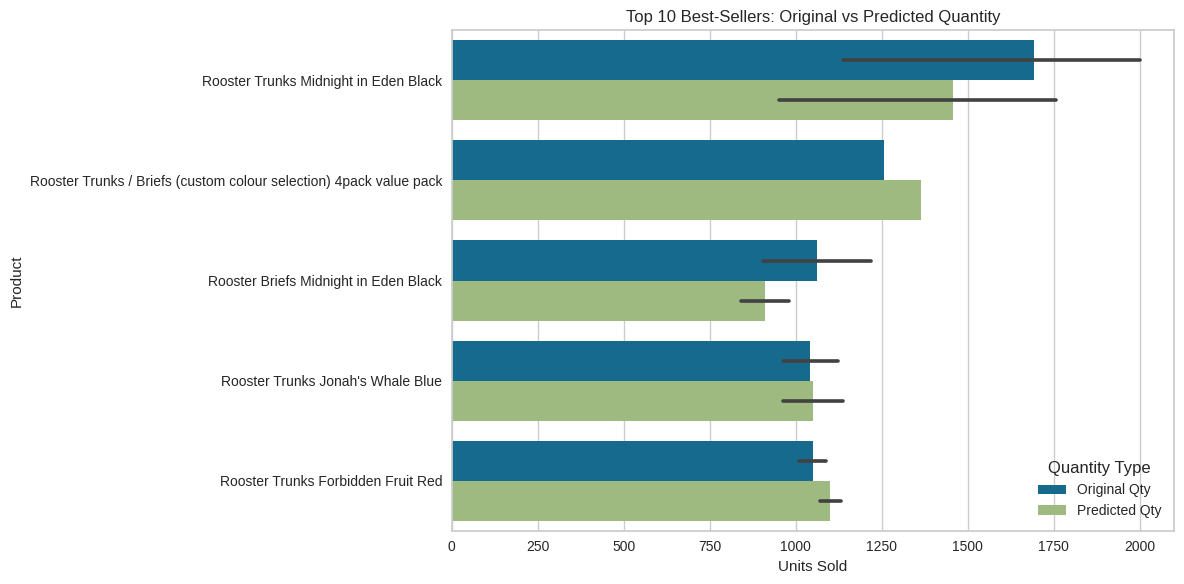

In [41]:
qty_melt = top10.melt(
    id_vars='product_name',
    value_vars=['old_qty','pred_qty'],
    var_name='Quantity Type',
    value_name='Units Sold'
)
qty_melt['Quantity Type'] = qty_melt['Quantity Type'].map({
    'old_qty':'Original Qty','pred_qty':'Predicted Qty'
})

plt.figure(figsize=(12,6))
sns.barplot(x='Units Sold', y='product_name', hue='Quantity Type', data=qty_melt)
plt.title('Top 10 Best‑Sellers: Original vs Predicted Quantity')
plt.xlabel('Units Sold'); plt.ylabel('Product')
plt.tight_layout()
plt.show()

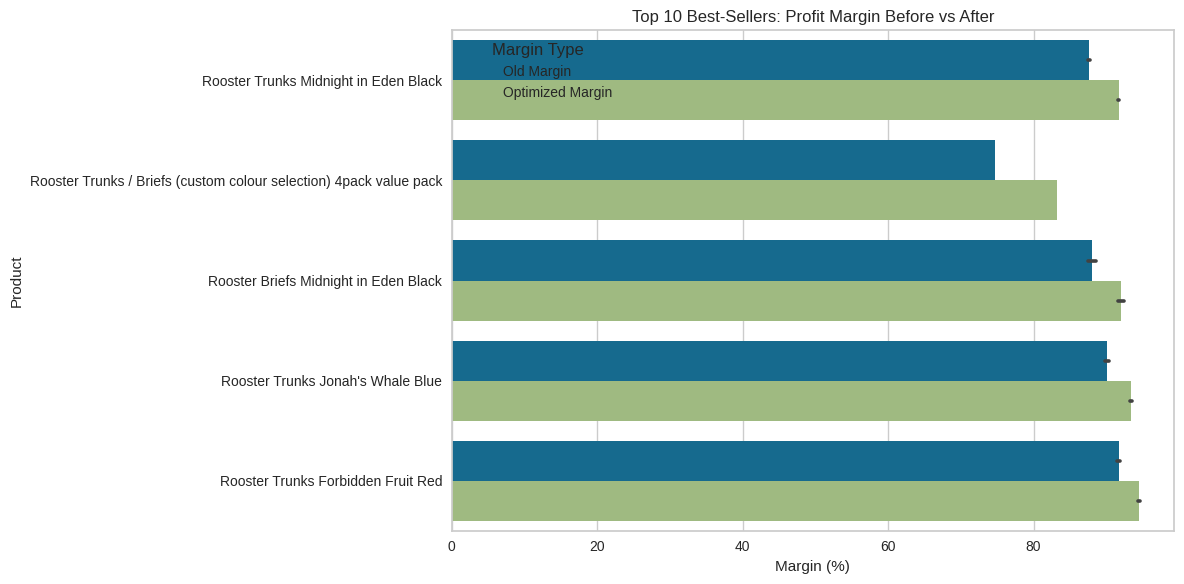

In [42]:
marg_melt = top10.melt(
    id_vars='product_name',
    value_vars=['old_margin_pct','opt_margin_pct'],
    var_name='Margin Type',
    value_name='Margin (%)'
)
marg_melt['Margin Type'] = marg_melt['Margin Type'].map({
    'old_margin_pct':'Old Margin','opt_margin_pct':'Optimized Margin'
})

plt.figure(figsize=(12,6))
sns.barplot(x='Margin (%)', y='product_name', hue='Margin Type', data=marg_melt)
plt.title('Top 10 Best‑Sellers: Profit Margin Before vs After')
plt.xlabel('Margin (%)'); plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [43]:
print("\nTop 10 Best‑Sellers: Price & Profit Impact")
print(top10[[
    'product_name','old_price','sim_price',
    'old_qty','pred_qty',
    'old_margin_pct','opt_margin_pct'
]].to_string(index=False, float_format='%.2f'))


Top 10 Best‑Sellers: Price & Profit Impact
                                                      product_name  old_price  sim_price  old_qty  pred_qty  old_margin_pct  opt_margin_pct
                             Rooster Trunks Midnight in Eden Black      16.90      25.35     2000   1665.43           87.45           91.64
                             Rooster Trunks Midnight in Eden Black      16.90      25.35     1939   1756.80           87.71           91.81
Rooster Trunks / Briefs (custom colour selection) 4pack value pack      63.60      95.40     1258   1365.77           74.74           83.16
                             Rooster Briefs Midnight in Eden Black      16.90      25.35     1219    980.65           88.56           92.37
                             Rooster Trunks Midnight in Eden Black      16.90      25.35     1138    951.78           87.63           91.76
                                 Rooster Trunks Jonah's Whale Blue      16.90      25.35     1122   1136.22         

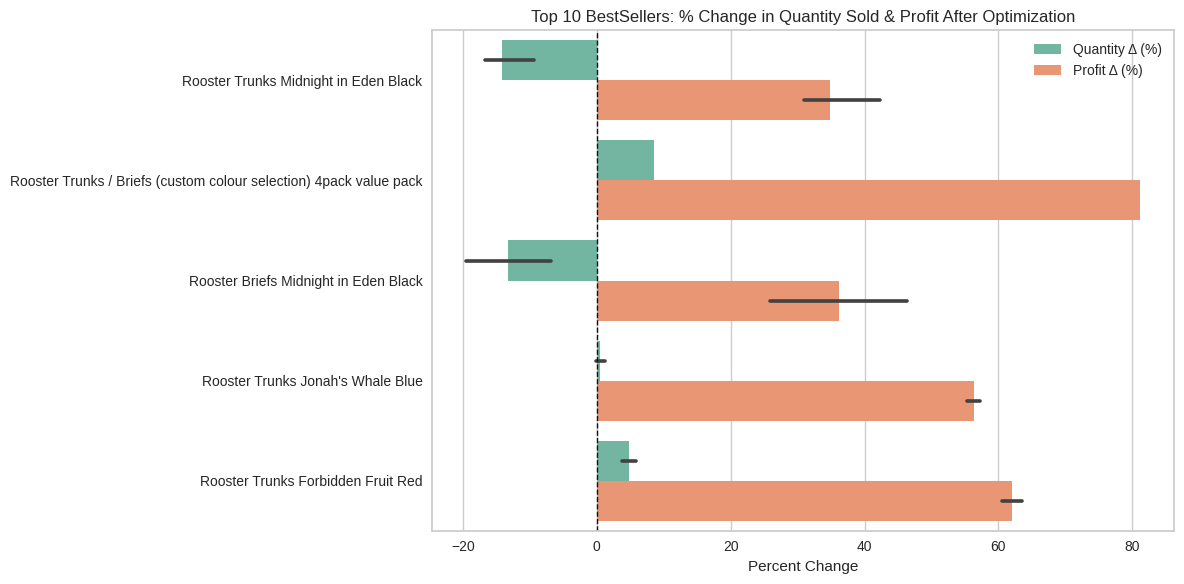


Top 10 BestSellers: % Change in Quantity Sold & Profit
                                                      product_name  Quantity Δ (%)  Profit Δ (%)
                             Rooster Trunks Midnight in Eden Black          -16.73         30.88
                             Rooster Trunks Midnight in Eden Black           -9.40         42.25
Rooster Trunks / Briefs (custom colour selection) 4pack value pack            8.57         81.19
                             Rooster Briefs Midnight in Eden Black          -19.55         25.87
                             Rooster Trunks Midnight in Eden Black          -16.36         31.36
                                 Rooster Trunks Jonah's Whale Blue            1.27         57.32
                                Rooster Trunks Forbidden Fruit Red            3.82         60.56
                                Rooster Trunks Forbidden Fruit Red            5.87         63.49
                                 Rooster Trunks Jonah's Whale Blue     

In [44]:
opt_df['qty_pct_change']    = (opt_df['pred_qty'] - opt_df['old_qty']) / opt_df['old_qty'] * 100
opt_df['profit_pct_change'] = (opt_df['profit']   - opt_df['old_profit']) / opt_df['old_profit'] * 100

top10 = opt_df.nlargest(10, 'old_qty').reset_index(drop=True)

pct_melt = top10.melt(
    id_vars='product_name',
    value_vars=['qty_pct_change', 'profit_pct_change'],
    var_name='Metric',
    value_name='Percent Change'
)
pct_melt['Metric'] = pct_melt['Metric'].map({
    'qty_pct_change'   : 'Quantity Δ (%)',
    'profit_pct_change': 'Profit Δ (%)'
})

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pct_melt,
    x='Percent Change',
    y='product_name',
    hue='Metric',
    palette='Set2'
)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.title('Top 10 BestSellers: % Change in Quantity Sold & Profit After Optimization')
plt.xlabel('Percent Change')
plt.ylabel('')
plt.legend(title='')
plt.tight_layout()
plt.show()

print("\nTop 10 BestSellers: % Change in Quantity Sold & Profit")
print(
    top10[['product_name','qty_pct_change','profit_pct_change']]
    .rename(columns={
        'qty_pct_change'   : 'Quantity Δ (%)',
        'profit_pct_change': 'Profit Δ (%)'
    })
    .to_string(index=False, float_format='%.2f')
)

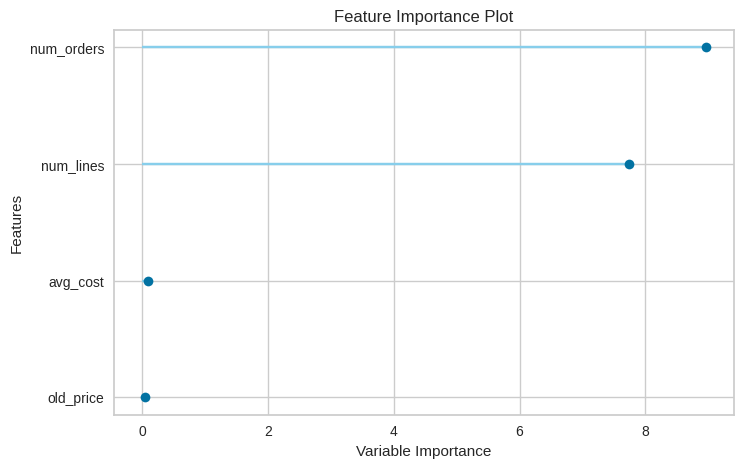

In [45]:
(plot_model(final_agg, 'feature'))

Correlation of 'qty_minus_refund' with other numeric columns:
qty_minus_refund                  1.000000
order_cost                        0.400606
order_units                       0.371516
order_qty_minus_refund            0.358121
order_total                       0.341677
order_subtotal_inc_tax            0.339185
discount_amount_inc_tax           0.207612
cart_discount                     0.123648
order_seq                         0.097196
line_id                           0.089040
order_qty_charged                 0.029889
discount_pc                       0.024698
order_dow                         0.020674
order_total_fee_inc               0.002906
order_refund                     -0.003609
item_discount_amount_and_tax     -0.059498
line_discount_amount_inc_tax     -0.073762
qty_charged                      -0.095799
cost                             -0.103573
pack_size                        -0.104170
units                            -0.116184
price                            -0

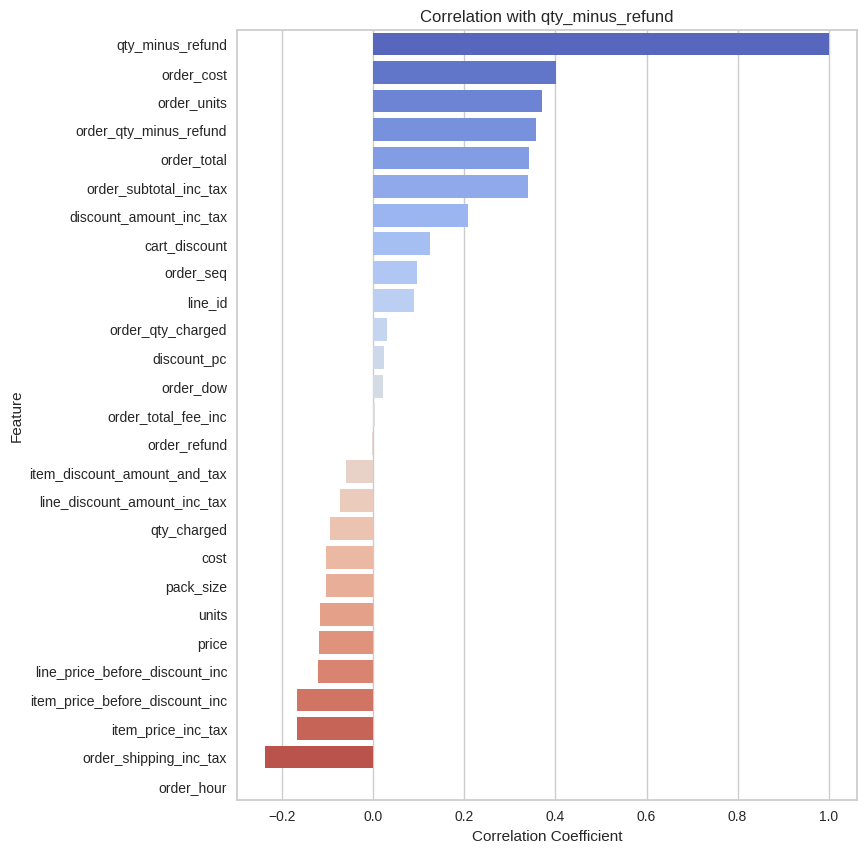

In [46]:
# prompt: from merged_df, find correlation between the column "qty_minus_refund" and all other columns. this should help build a stronger model right?

import matplotlib.pyplot as plt
# Calculate the correlation matrix for the merged dataframe
correlation_matrix = merged_df.corr(numeric_only=True)

# Get the correlation of 'qty_minus_refund' with all other columns
correlation_with_qty = correlation_matrix['qty_minus_refund'].sort_values(ascending=False)

print("Correlation of 'qty_minus_refund' with other numeric columns:")
print(correlation_with_qty)

# Visualize the correlation with 'qty_minus_refund'
plt.figure(figsize=(8, 10))
sns.barplot(x=correlation_with_qty.values, y=correlation_with_qty.index, palette='coolwarm')
plt.title('Correlation with qty_minus_refund')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

# Classifier

In [47]:
# 1. Merge dataframes to get relevant features
# Start with customers and metrics
customer_repeat_df = customers_df.merge(metrics_df[['customer_email', 'repeat_customer']], on='customer_email', how='left')

# Merge with orders and orderlines to get order/product level details
customer_order_details = customer_repeat_df.merge(orders_df, on='customer_email', how='left')
customer_order_details = customer_order_details.merge(orderlines_df, on='order_id', how='left')
customer_order_details = customer_order_details.merge(products_df, on='pvr_id', how='left')

In [48]:
customer_order_details_with_sim = customer_order_details.merge(
    grid_df[['pvr_id', 'sim_price']],
    on='pvr_id',
    how='left'
)

# Calculate the price change percentage for each order line
customer_order_details_with_sim['price_change_pct'] = (
    (customer_order_details_with_sim['sim_price'] - customer_order_details_with_sim['price']) /
    customer_order_details_with_sim['price']
)

In [49]:
# Aggregate price change percentage at the customer level
customer_price_impact = customer_order_details_with_sim.groupby('customer_email')[
    'price_change_pct'
].mean().reset_index()
customer_price_impact.rename(
    columns={'price_change_pct': 'avg_price_increase_pct'}, inplace=True
)

# Merge this back into the main customer repeat dataframe
customer_repeat_df = customer_repeat_df.merge(
    customer_price_impact, on='customer_email', how='left'
)

In [50]:
# Handle potential NaNs for customers who didn't place orders in the historical data
customer_repeat_df['avg_price_increase_pct'].fillna(0, inplace=True)

In [51]:
classification_features = [
    'customer_total_orders',
    'customer_total_spent',
    'avg_price_increase_pct',
    # Add other potentially relevant features from customers_df if needed
    # 'customer_city', 'customer_country', etc. - remember to handle categorical features
]

In [52]:
classification_data = customer_repeat_df[
    classification_features + ['repeat_customer']
].dropna() # Drop rows with NaN in selected columns

In [53]:
# Ensure the target variable is integer type
classification_data['repeat_customer'] = classification_data[
    'repeat_customer'
].astype(int)

In [54]:
# 3. Build Classification Model using PyCaret
from pycaret.classification import *

# Setup PyCaret classification environment
# 'repeat_customer' is the target variable
# session_id for reproducibility
clf_exp = setup(
    data=classification_data,
    target='repeat_customer',
    session_id=123,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95
)

# Compare models to find the best performing one
best_model = compare_models()

,Description,Value
0,Session id,123
1,Target,repeat_customer
2,Target type,Binary
3,Original data shape,"(9131, 4)"
4,Transformed data shape,"(9131, 4)"
5,Transformed train set shape,"(6391, 4)"
6,Transformed test set shape,"(2740, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0310
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0290
svm,SVM - Linear Kernel,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0290
ridge,Ridge Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0280
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3790
ada,Ada Boost Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0350
gbc,Gradient Boosting Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1520
lda,Linear Discriminant Analysis,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0270
et,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1700
xgboost,Extreme Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0540


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [55]:
# Print the best model
best_model

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [56]:
# Finalize the model
final_clf_model = finalize_model(best_model)

# Make predictions on the original data (optional, for analysis)
predictions = predict_model(final_clf_model, data=classification_data)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [57]:
# You can now analyze the 'Label' and 'Score' columns in the predictions dataframe
print("\nPredictions with repeat customer probability:")
predictions.head()


Predictions with repeat customer probability:


,customer_total_orders,customer_total_spent,avg_price_increase_pct,repeat_customer,prediction_label,prediction_score
0,2,93.769997,0.25,1,1,0.9963
1,1,16.799999,0.25,0,0,0.9995
2,1,18.959999,0.25,0,0,0.9995
3,2,67.599998,0.25,1,1,0.9945
4,2,93.199997,0.25,1,1,0.9963



Feature Importance:


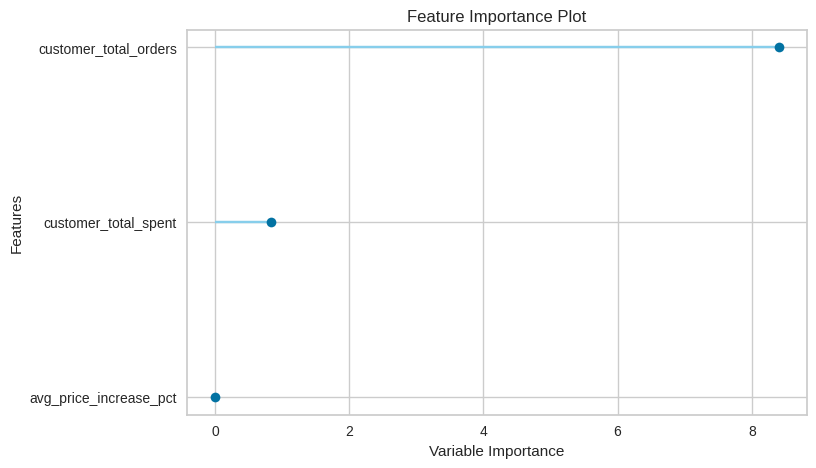

In [58]:
# To see the feature importance of the final model:
print('\nFeature Importance:')
plot_model(final_clf_model, plot='feature')

In [59]:
# Ensure you have classification_data and final_clf_model from previous steps

# 1. Identify Actual Repeat Customers
actual_repeat_customers = classification_data['repeat_customer'].sum()
print(f"Actual number of repeat customers: {actual_repeat_customers}")

# 2. Estimate Predicted Repeat Customers without Price Increase
# Create a temporary dataframe without the 'avg_price_increase_pct' feature
classification_data_no_price_impact = classification_data.drop(columns=['avg_price_increase_pct'])

# Setup PyCaret for classification without the price impact feature
# Need to run setup again with the modified data
print("\nSetting up classification without price impact feature...")
# Re-import setup if running this cell independently
from pycaret.classification import setup, predict_model

clf_exp_no_impact = setup(
    data=classification_data_no_price_impact,
    target='repeat_customer',
    session_id=123,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    verbose=False # Suppress verbose output for the setup
)

# Use the best model identified earlier, or re-run compare_models if needed
# The previous best model was LogisticRegression, which corresponds to 'lr' in PyCaret.
# Train a Logistic Regression model specifically on the data without price impact
from pycaret.classification import create_model, finalize_model

# Use the PyCaret model ID 'lr' for Logistic Regression
model_no_impact = create_model('lr', verbose=False) # Suppress verbose output for create_model
final_model_no_impact = finalize_model(model_no_impact)


predictions_no_price_impact = predict_model(final_model_no_impact, data=classification_data_no_price_impact)

# Count predicted repeat customers (where the model predicts Label = 1)
predicted_repeat_customers_no_impact = predictions_no_price_impact['prediction_label'].sum()
print(f"Predicted number of repeat customers without price increase: {predicted_repeat_customers_no_impact}")

# 3. Estimate Predicted Repeat Customers with Price Increase
# You already have the predictions with price impact in the 'predictions' DataFrame
predicted_repeat_customers_with_impact = predictions['prediction_label'].sum()
print(f"Predicted number of repeat customers with price increase: {predicted_repeat_customers_with_impact}")

# 4. Compare Predicted Counts
change_in_predicted_repeat_customers = predicted_repeat_customers_with_impact - predicted_repeat_customers_no_impact
print(f"\nEstimated change in predicted repeat customers: {change_in_predicted_repeat_customers}")

# Calculate percentage change
if predicted_repeat_customers_no_impact != 0:
    percentage_change = (change_in_predicted_repeat_customers / predicted_repeat_customers_no_impact) * 100
    print(f"Estimated percentage change in predicted repeat customers: {percentage_change:.2f}%")
else:
    print("Cannot calculate percentage change as predicted repeat customers without price increase is 0.")

Actual number of repeat customers: 2059

Setting up classification without price impact feature...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Predicted number of repeat customers without price increase: 2059
Predicted number of repeat customers with price increase: 2059

Estimated change in predicted repeat customers: 0
Estimated percentage change in predicted repeat customers: 0.00%


The delta in repeat customers being zero, despite the lower volume of products being sold predicted buy the regression model can be explained by the repeat customers simply buying less units per order rather than never buying from the store again. the repeat customer flag only explains that the customer has placed more than one order across the period covered by the dataset

# Excel for tableau

In [60]:

dataframes_to_export = {
    'Customers': customers_df,
    'Orders': orders_df,
    'Products': products_df,
    'OrderLines': orderlines_df,
    'Metrics': metrics_df,
    'RegressionResults': opt_df,  # Results from your regression model
    'ClassificationPredictions': predictions # Predictions from your classification model
}

excel_file_name = 'rooster_analysis_data.xlsx'

with pd.ExcelWriter(excel_file_name) as writer:
    for sheet_name, df in dataframes_to_export.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Data successfully exported to '{excel_file_name}' with multiple sheets.")

Data successfully exported to 'rooster_analysis_data.xlsx' with multiple sheets.
